Trabajas en una empresa que produce maquinas de ejercicio. Un gimnacia local ha solicitado que las maquinas esten adaptadas a sus métodos de entrenamiento.
para esto les ha proporcionado una base de datos. Al gimnaso le interesa predecir las calorias quemadas con la mayor precision posible sin ser demasiado invasivos con sus clientes.

In [ ]:
link='https://raw.githubusercontent.com/karenrosas0410-pixel/Estad-stica-2026B-/refs/heads/main/gym_members_exercise_tracking.csv'

import pandas as pd
df=pd.read_csv(link)
df

,Edad,Genero,Peso(kg),Altura(m),Max_BPM,Promedio_bpm,Reposo_bpm,Duracion,Calorias_quemadas,Tipo_entrenamiendo,Fat_Porcentaje_grasa,Consumo_agua,Frecuencia_entrenamiento,Nivel_experiencia,bmi
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,Male,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,Male,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,Female,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,Male,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Edad                      973 non-null    int64  
 1   Genero                    973 non-null    object 
 2   Peso(kg)                  973 non-null    float64
 3   Altura(m)                 973 non-null    float64
 4   Max_BPM                   973 non-null    int64  
 5   Promedio_bpm              973 non-null    int64  
 6   Reposo_bpm                973 non-null    int64  
 7   Duracion                  973 non-null    float64
 8   Calorias_quemadas         973 non-null    float64
 9   Tipo_entrenamiendo        973 non-null    object 
 10  Fat_Porcentaje_grasa      973 non-null    float64
 11  Consumo_agua              973 non-null    float64
 12  Frecuencia_entrenamiento  973 non-null    int64  
 13  Nivel_experiencia         973 non-null    int64  
 14  bmi       

In [ ]:
df.dropna(inplace = True)

In [ ]:
df.describe()

,Edad,Peso(kg),Altura(m),Max_BPM,Promedio_bpm,Reposo_bpm,Duracion,Calorias_quemadas,Fat_Porcentaje_grasa,Consumo_agua,Frecuencia_entrenamiento,Nivel_experiencia,bmi
count,973.000000,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000,973.000000
mean,38.683453,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,29.300000,3.100000,4.000000,2.000000,28.560000
max,59.000000,129.900000,2.00000,199.000000,169.000000,74.000000,2.000000,1783.000000,35.000000,3.700000,5.000000,3.000000,49.840000


Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj  lower   upper  reject
---------------------------------------------------
Female   Male  82.2071   0.0 48.2331 116.181   True
---------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

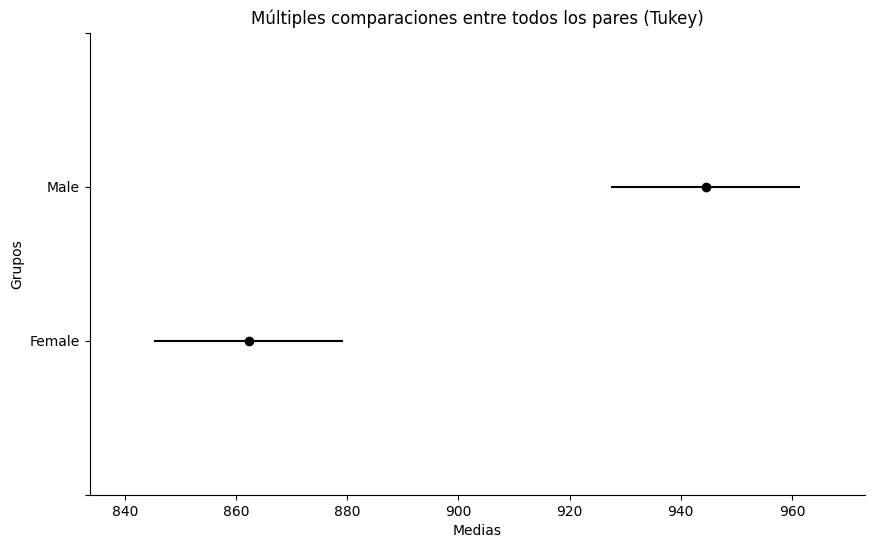

In [ ]:
# test de tukey
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calorias_quemadas'], groups=df['Genero'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df["Genero"]=df["Genero"].map({"Female":0,"Male":1})
df

,Edad,Genero,Peso(kg),Altura(m),Max_BPM,Promedio_bpm,Reposo_bpm,Duracion,Calorias_quemadas,Tipo_entrenamiendo,Fat_Porcentaje_grasa,Consumo_agua,Frecuencia_entrenamiento,Nivel_experiencia,bmi
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,Strength,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,Strength,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,Cardio,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,HIIT,28.2,2.1,3,2,37.74


   Multiple Comparison of Means - Tukey HSD, FWER=0.05    
 group1   group2  meandiff p-adj   lower    upper   reject
----------------------------------------------------------
  Cardio     HIIT  41.2917 0.3523 -23.1974 105.7809  False
  Cardio Strength  26.1839 0.6973 -35.7784  88.1463  False
  Cardio     Yoga  18.6746 0.8721 -44.5002  81.8494  False
    HIIT Strength -15.1078 0.9306 -79.4226  49.2071  False
    HIIT     Yoga -22.6171 0.8107 -88.1009  42.8666  False
Strength     Yoga  -7.5094   0.99 -70.5062  55.4875  False
----------------------------------------------------------


Text(0.5, 1.0, 'Múltiples comparaciones entre todos los pares (Tukey)')

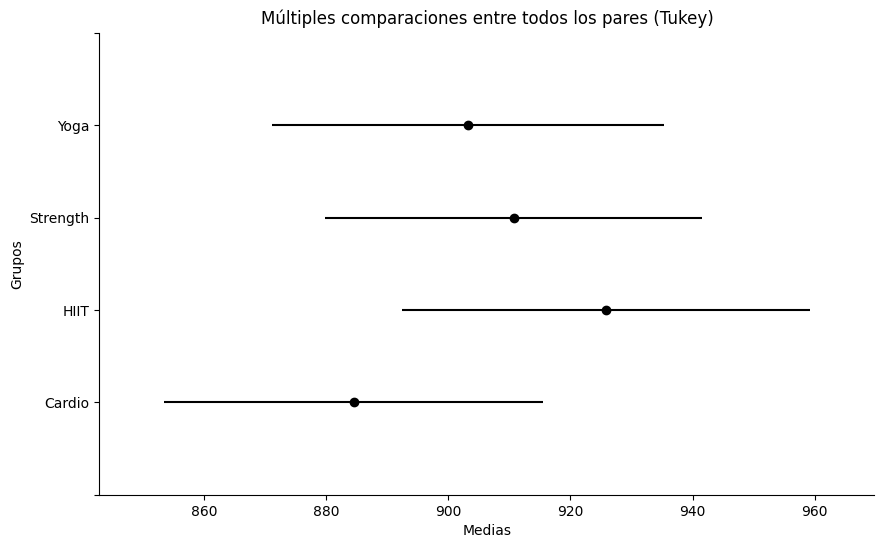

In [ ]:
# test de tukey
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt

nivel_de_significancia = 0.05

# Prueba de Tukey
tukey = pairwise_tukeyhsd(endog=df['Calorias_quemadas'], groups=df['Tipo_entrenamiendo'], alpha=nivel_de_significancia)

# Mostrar los resultados
print(tukey)

# Gráfico de las diferencias entre grupos
tukey.plot_simultaneous(ylabel="Grupos", xlabel="Medias")

plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior
plt.title("Múltiples comparaciones entre todos los pares (Tukey)")

In [ ]:
df["Tipo_entrenamiendo"]=df["Tipo_entrenamiendo"].map({"Cardio":0,"Yoga":1,"Strength":2,"HIIT":3})
df

,Edad,Genero,Peso(kg),Altura(m),Max_BPM,Promedio_bpm,Reposo_bpm,Duracion,Calorias_quemadas,Tipo_entrenamiendo,Fat_Porcentaje_grasa,Consumo_agua,Frecuencia_entrenamiento,Nivel_experiencia,bmi
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,1,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,3,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,24,1,87.1,1.74,187,158,67,1.57,1364.0,2,10.0,3.5,4,3,28.77
969,25,1,66.6,1.61,184,166,56,1.38,1260.0,2,25.0,3.0,2,1,25.69
970,59,0,60.4,1.76,194,120,53,1.72,929.0,0,18.8,2.7,5,3,19.50
971,32,1,126.4,1.83,198,146,62,1.10,883.0,3,28.2,2.1,3,2,37.74


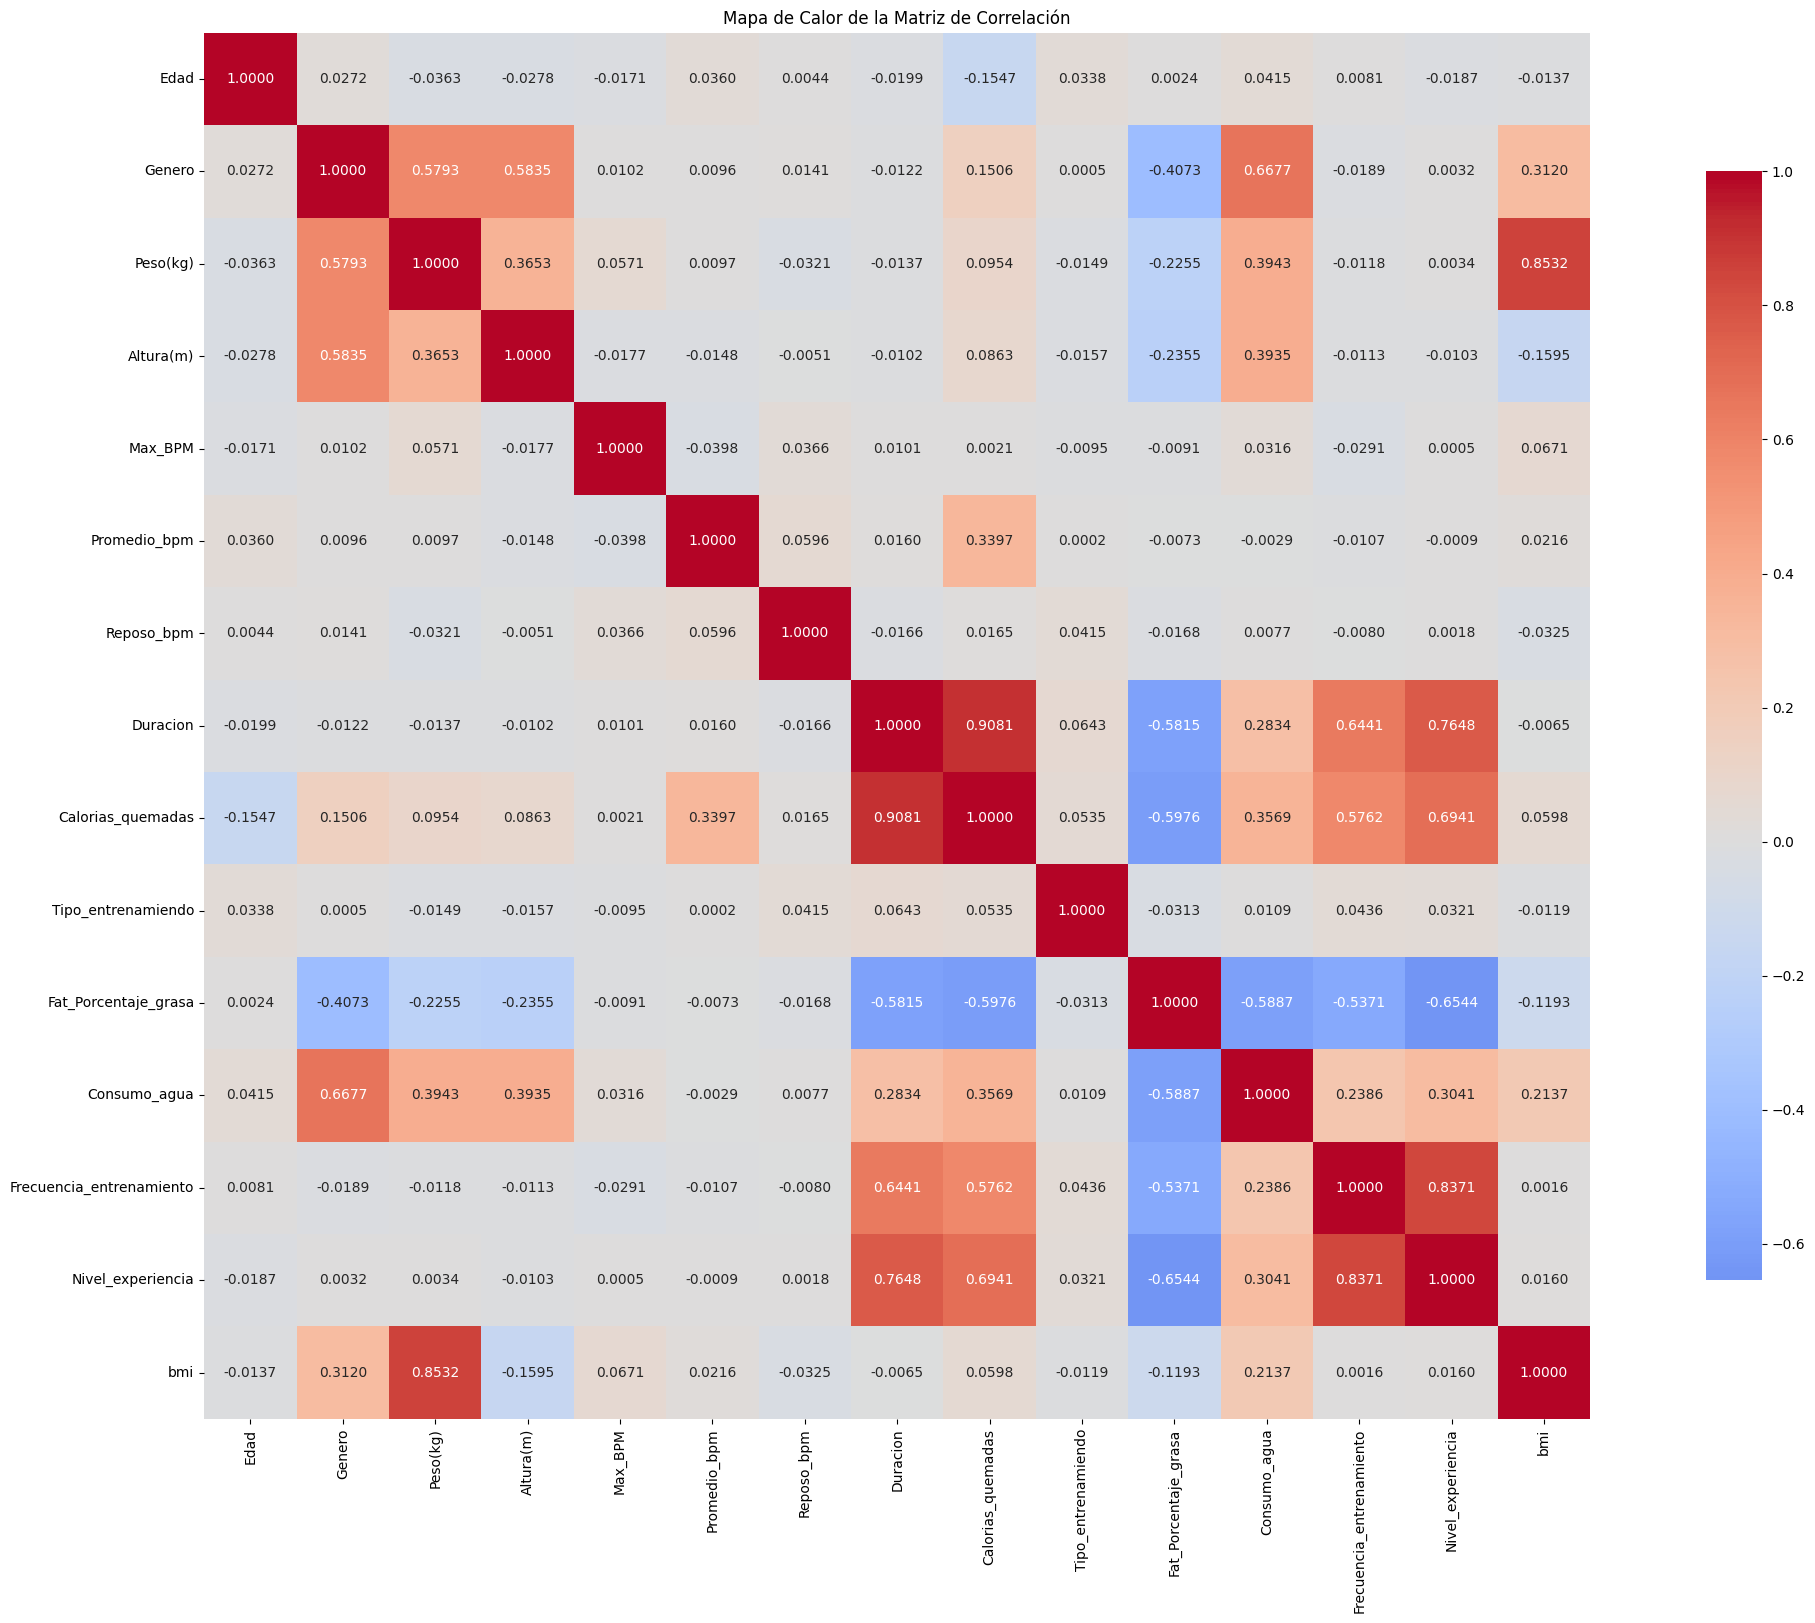

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
plt.figure(figsize=(30, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".4f",
            square=True,
            center=0,
            cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()

In [ ]:
#Analisis de multicolinealidad
df=df[["Duracion","Nivel_experiencia","Frecuencia_entrenamiento","Genero","Edad","Calorias_quemadas"]]
df

,Duracion,Nivel_experiencia,Frecuencia_entrenamiento,Genero,Edad,Calorias_quemadas
0,1.69,3,4,1,56,1313.0
1,1.30,2,4,0,46,883.0
2,1.11,2,4,0,32,677.0
3,0.59,1,3,1,25,532.0
4,0.64,1,3,1,38,556.0
...,...,...,...,...,...,...
968,1.57,3,4,1,24,1364.0
969,1.38,1,2,1,25,1260.0
970,1.72,3,5,0,59,929.0
971,1.10,2,3,1,32,883.0


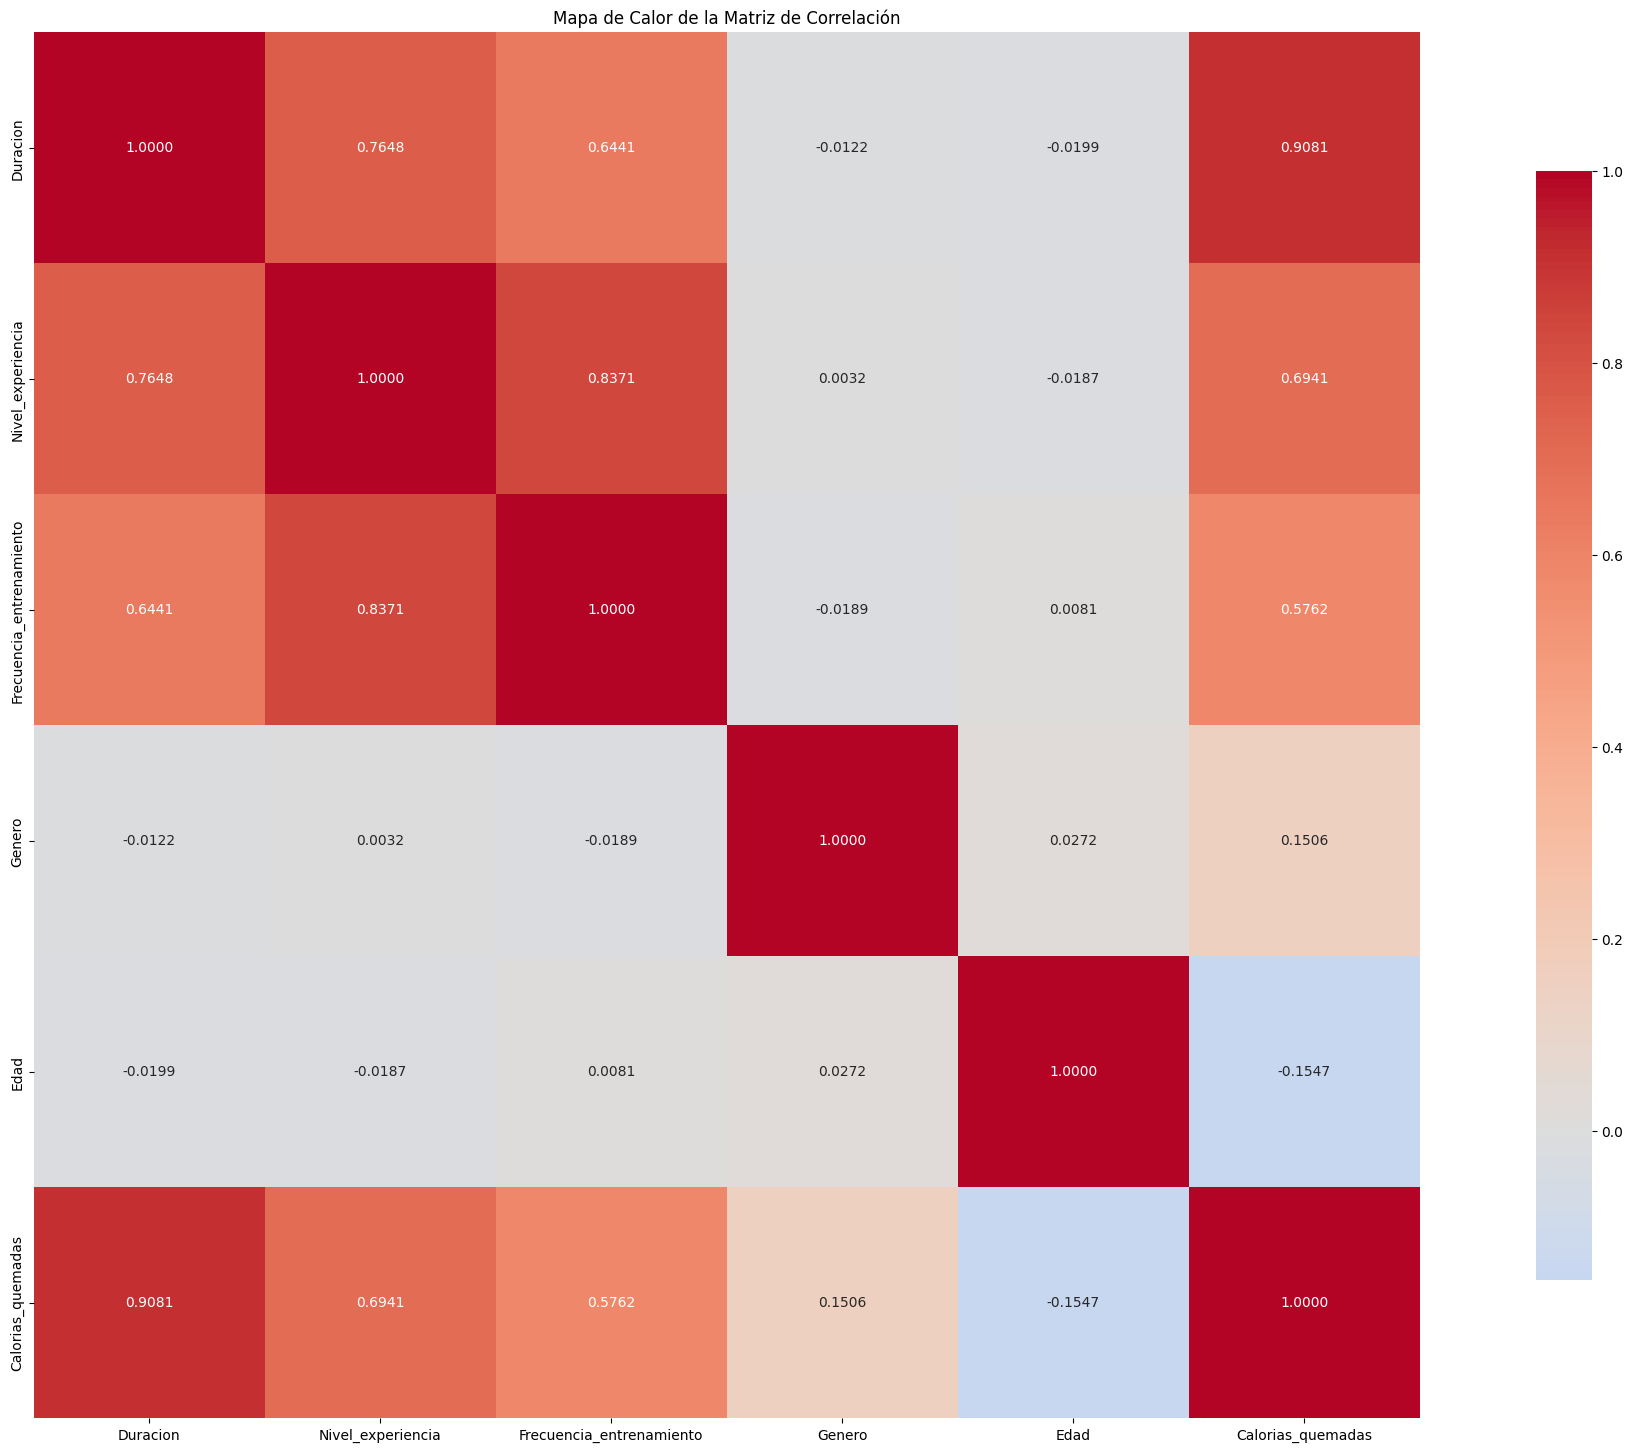

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df.corr()
plt.figure(figsize=(30, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            fmt=".4f",
            square=True,
            center=0,
            cbar_kws={"shrink": .8})
plt.title('Mapa de Calor de la Matriz de Correlación')
plt.show()


In [ ]:
x=df[["Duracion","Frecuencia_entrenamiento","Genero","Edad"]]
y=df["Calorias_quemadas"]

In [ ]:
# 6. Obtenga la recta de regresión ajustada y grafíquelo sobre el
# gráfico de dispersión

import statsmodels.api as sm
x_constante = sm.add_constant(x)
modelo = sm.OLS(y, x_constante).fit()
y_calculada = modelo.predict(x_constante)

modelo.params

,0
const,76.383259
Duracion,724.702457
Frecuencia_entrenamiento,-2.066399
Genero,90.296443
Edad,-3.155146


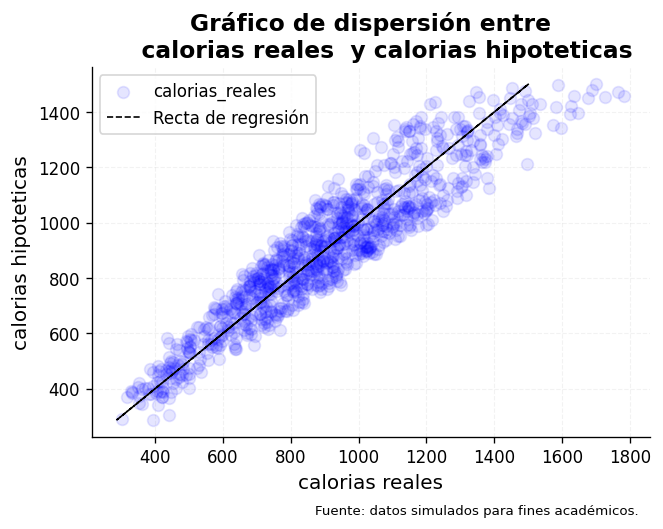

In [ ]:
# @title
# 2. Realice un diagrama de dispersión para estos datos.
import matplotlib.pyplot as plt

# --- Configuración general del gráfico ---
plt.figure(
    figsize=(6, 4),   # tamaño de la figura (ancho, alto) en pulgadas
    dpi=120           # resolución del gráfico
)

# --- Gráfico de dispersión ---
plt.scatter(
    y, y_calculada,
    marker="o",       # forma
    color='blue',     # color de los puntos
    edgecolor='Blue',    # borde de los puntos
    alpha=0.1,            # transparencia
    s=50,                 # tamaño de los puntos
    label='calorias_reales' # etiqueta para la leyenda
)

# --- Gráfico de línea ---
plt.plot(
    y_calculada, y_calculada,
    color='black',   # color de la línea
    linewidth=1,        # grosor de la línea
    linestyle='--',        # estilo de línea
    marker='o',           # marcador en cada punto
    markersize=0,         # tamaño del marcador
    markerfacecolor='white',
    markeredgecolor='black',
    label='Recta de regresión'
)

# --- Título ---
plt.title(
    '''Gráfico de dispersión entre
    calorias reales  y calorias hipoteticas''',
    fontsize=14,
    fontweight='bold'
)

# --- Etiquetas de los ejes ---
plt.xlabel(
    'calorias reales',
    fontsize=12
)

plt.ylabel(
    'calorias hipoteticas',
    fontsize=12
)

# --- Fuente de los ticks ---
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

# --- Márgenes ---
plt.margins(x=0.05, y=0.05)  # espacio extra alrededor de los datos
plt.gca().spines['right'].set_visible(False) # derecha
plt.gca().spines['top'].set_visible(False)   # superior

# Para eliminar márgenes completamente, usar:
# plt.margins(0)

# --- Cuadrícula (opcional, pero didáctica) ---
plt.grid(
    visible=True,
    linestyle='--',
    linewidth=0.7,
    alpha=0.1,
    color="gray"
)

# --- Leyenda ---
plt.legend(
    fontsize=10,
    loc='best',
    frameon=True
)

# --- Nota al pie ---
plt.text(
    0.4, -0.2,
    'Fuente: datos simulados para fines académicos.',
    fontsize=8,
    ha='left',
    va='center',
    transform=plt.gca().transAxes
)

# --- Guardar gráfico ---
plt.savefig(
    "grafico de dispersión",
    bbox_inches='tight'
    )

plt.show()

In [ ]:
# 5. Calcule el coeficiente de determinación e interprete el resultado.
from sklearn.metrics import r2_score  # recomendada
r2 = r2_score(y, y_calculada)
print(f'Coeficiente de determinación: {r2: 0.2%}\n')

Coeficiente de determinación:  87.08%



In [ ]:
modelo.params

,0
const,76.383259
Duracion,724.702457
Frecuencia_entrenamiento,-2.066399
Genero,90.296443
Edad,-3.155146


In [ ]:
# 7. Obtenga un intervalo de confianza del 95% para la pendiente de la recta de
# regresión ajustada ( b1 )

# intervalo de confianza = 1 - alpha

modelo.conf_int(alpha = 0.05)

,0,1
const,43.356599,109.409919
Duracion,701.131745,748.273169
Frecuencia_entrenamiento,-10.921509,6.788712
Genero,77.917543,102.675343
Edad,-3.663088,-2.647204


valor-p (Shapiro) = 0.0026221034152768405


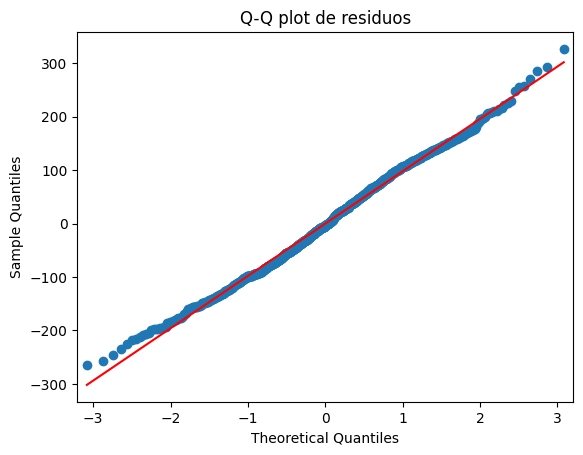

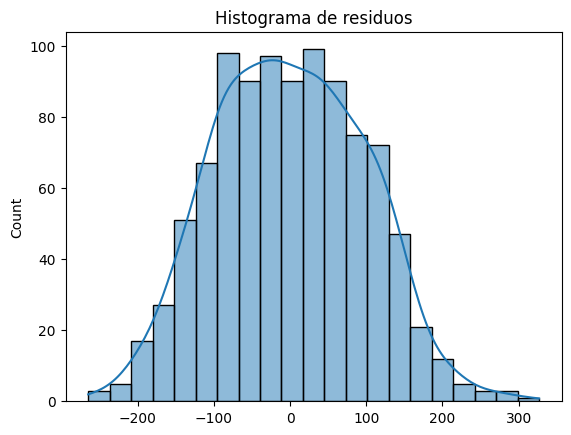

In [ ]:
residuales=modelo.resid
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns

# Prueba de Shapiro-Wilk
stat, valor_p_sh = shapiro(residuales)
print(f"valor-p (Shapiro) = {valor_p_sh}")

# Visualización: Q-Q plot
sm.qqplot(residuales, line='s')
plt.title("Q-Q plot de residuos")
plt.show()

# Histograma
sns.histplot(residuales, kde=True)
plt.title("Histograma de residuos")
plt.show()

In [ ]:
#10 Test de Breusch-Pagan
from statsmodels.stats.api import het_breuschpagan
estadistico_1,valor_p_1,estadistico_2,valor_p_2=het_breuschpagan(residuales,x_constante)
print(f"valor_p:{valor_p_1:0.4f}")
# si el valor es menor a sigma s rechaza H0

valor_p:0.0000


In [ ]:
# 12. Realice una tabla ANOVA e interprete el resultado.

# test de ANOVA (Analysis of Variance)
# H0: beta_1 = 0   (No hay correlación)
# H1: beta_1 ≠ 0   (Sí hay correlación)

from statsmodels.formula.api import ols
# Y ~ X
modelo_lineal = ols('Calorias_quemadas ~ Duracion+Frecuencia_entrenamiento+Genero+Edad', data = df).fit()
tabla_anova = sm.stats.anova_lm(modelo_lineal)
tabla_anova

,df,sum_sq,mean_sq,F,PR(>F)
Duracion,1.0,5.958764e+07,5.958764e+07,6178.813317,0.000000e+00
Frecuencia_entrenamiento,1.0,9.606055e+03,9.606055e+03,0.996079,3.185105e-01
Genero,1.0,1.886554e+06,1.886554e+06,195.622211,1.272222e-40
Edad,1.0,1.432996e+06,1.432996e+06,148.591438,6.711290e-32
Residual,968.0,9.335262e+06,9.643865e+03,NaN,NaN
